In [1]:
# 고전 컴퓨터비전(Classical CV) 실습 — SIFT / ORB 특징점 매칭(Feature Matching)
#
# "여러 스케일에서 두드러진 지점(keypoint)을 찾고, 주변 패턴을 벡터(descriptor)로
# 인코딩하여 서로 다른 두 이미지 간에 같은 지점을 매칭"하는 과정을 4개 계층으로
# 분리해 구현한다. SIFT와 ORB를 "같은 인터페이스를 구현하는 서로 교체 가능한
# 어댑터"로 두어, 한 벌의 유스케이스 코드로 두 알고리즘을 모두 실행·비교한다.
#
# Clean Architecture 레이어:
#   [도메인 계층]      — 값 객체(dataclass) + 추상 인터페이스(abc.ABC). cv2 비의존.
#   [유스케이스 계층]   — FeatureMatchingUseCase. 인터페이스만 주입받아 흐름을 조립.
#   [인프라 계층]      — cv2 SIFT/ORB + BFMatcher 기반 실제 구현체(추출/매칭/시각화 분리).
#   [구성 루트]        — Colab 셀: 이미지 준비, DI 조립, matplotlib 시각화/저장.

## 셀 1: 환경 준비

In [2]:
# !pip install opencv-python-headless scikit-image matplotlib numpy --quiet
# (한글 폰트가 없는 환경이면) !apt-get -qq install -y fonts-nanum && fc-cache -f
from __future__ import annotations

import numpy as np
import matplotlib
from matplotlib import font_manager as _font_manager
import glob as _glob
for _font_path in _glob.glob("/usr/share/fonts/truetype/nanum/NanumGothic.ttf"):
    _font_manager.fontManager.addfont(_font_path)  # 폰트 매니저에 명시적으로 등록
matplotlib.rcParams["font.family"] = "NanumGothic"  # 그래프 한글 깨짐 방지
matplotlib.rcParams["axes.unicode_minus"] = False

# ===== [도메인 계층 / Domain Layer] =====

from abc import ABC, abstractmethod
from dataclasses import dataclass


@dataclass(frozen=True)
class FeatureSet:
    """한 이미지에서 추출한 특징점·서술자 묶음. keypoints는 시각화를 위해
    좌표(x, y)만 순수 파이썬 튜플로 저장해, 도메인 계층이 cv2.KeyPoint
    타입을 몰라도 되게 한다."""
    keypoint_coords: list[tuple[float, float]]
    descriptors: np.ndarray | None


@dataclass(frozen=True)
class FeatureMatchResult:
    algorithm_name: str
    image_a_rgb: np.ndarray
    image_b_rgb: np.ndarray
    features_a: FeatureSet
    features_b: FeatureSet
    match_pairs: list[tuple[int, int]]  # (features_a의 인덱스, features_b의 인덱스)

    @property
    def match_count(self) -> int:
        return len(self.match_pairs)


class FeatureExtractor(ABC):
    """"이미지를 받아 특징점/서술자를 돌려준다"는 계약만 정의한다. SIFT와
    ORB가 이 인터페이스의 서로 다른 구현체가 되어 완전히 치환 가능하다(LSP)."""

    @property
    @abstractmethod
    def name(self) -> str:
        ...

    @abstractmethod
    def extract(self, gray_image: np.ndarray) -> FeatureSet:
        ...


class FeatureMatcher(ABC):
    """두 FeatureSet을 받아 매칭 인덱스 쌍을 돌려주는 책임만 갖는 작은
    인터페이스(ISP) — 추출 로직과 완전히 분리되어 있다."""

    @abstractmethod
    def match(self, features_a: FeatureSet, features_b: FeatureSet) -> list[tuple[int, int]]:
        ...


# ===== [유스케이스 계층 / Use Case Layer] =====

class FeatureMatchingUseCase:
    def __init__(self, extractor: FeatureExtractor, matcher: FeatureMatcher):
        self._extractor = extractor
        self._matcher = matcher

    def run(
        self,
        gray_a: np.ndarray, rgb_a: np.ndarray,
        gray_b: np.ndarray, rgb_b: np.ndarray,
    ) -> FeatureMatchResult:
        features_a = self._extractor.extract(gray_a)
        features_b = self._extractor.extract(gray_b)
        pairs = self._matcher.match(features_a, features_b)
        return FeatureMatchResult(
            algorithm_name=self._extractor.name,
            image_a_rgb=rgb_a, image_b_rgb=rgb_b,
            features_a=features_a, features_b=features_b,
            match_pairs=pairs,
        )


# ===== [인프라/어댑터 계층 / Infrastructure Layer] =====

import cv2


class SIFTFeatureExtractor(FeatureExtractor):
    """SIFT(Scale-Invariant Feature Transform) cv2 어댑터. 특허가 만료되어
    OpenCV 메인 배포판의 cv2.SIFT_create()로 바로 사용 가능하다."""

    def __init__(self, n_features: int = 500):
        self._sift = cv2.SIFT_create(nfeatures=n_features)

    @property
    def name(self) -> str:
        return "SIFT"

    def extract(self, gray_image: np.ndarray) -> FeatureSet:
        keypoints, descriptors = self._sift.detectAndCompute(gray_image, None)
        coords = [kp.pt for kp in keypoints]
        return FeatureSet(keypoint_coords=coords, descriptors=descriptors)


class ORBFeatureExtractor(FeatureExtractor):
    """ORB(Oriented FAST and Rotated BRIEF) cv2 어댑터. 특허가 없어 가볍고
    무료라 실무에서 SIFT 대신 많이 쓰인다."""

    def __init__(self, n_features: int = 500):
        self._orb = cv2.ORB_create(nfeatures=n_features)

    @property
    def name(self) -> str:
        return "ORB"

    def extract(self, gray_image: np.ndarray) -> FeatureSet:
        keypoints, descriptors = self._orb.detectAndCompute(gray_image, None)
        coords = [kp.pt for kp in keypoints]
        return FeatureSet(keypoint_coords=coords, descriptors=descriptors)


class RatioTestBFMatcher(FeatureMatcher):
    """Brute-Force 매칭 + Lowe's ratio test(오매칭 제거) cv2 어댑터. SIFT는
    실수(float) 서술자 → NORM_L2, ORB는 이진(binary) 서술자 → NORM_HAMMING을
    쓰도록 생성 시점에 norm_type을 주입받는다(DIP: 유스케이스는 이 차이를 모른다)."""

    def __init__(self, norm_type: int, ratio_threshold: float = 0.75):
        self._matcher = cv2.BFMatcher(norm_type)
        self._ratio_threshold = ratio_threshold

    def match(self, features_a: FeatureSet, features_b: FeatureSet) -> list[tuple[int, int]]:
        if features_a.descriptors is None or features_b.descriptors is None:
            return []
        knn_matches = self._matcher.knnMatch(features_a.descriptors, features_b.descriptors, k=2)
        good_pairs: list[tuple[int, int]] = []
        for pair in knn_matches:
            if len(pair) < 2:
                continue
            best, second_best = pair
            if best.distance < self._ratio_threshold * second_best.distance:
                good_pairs.append((best.queryIdx, best.trainIdx))
        return good_pairs


class FeatureMatchVisualizer:
    """시각화 전담 클래스(SRP) — 두 이미지를 나란히 놓고 매칭된 특징점을
    선으로 이어 저장한다. 계산 로직(추출/매칭)과는 완전히 독립적이다."""

    def __init__(self, title: str, max_lines_to_draw: int = 60):
        self._title = title
        self._max_lines = max_lines_to_draw

    def save_result(self, result: FeatureMatchResult, out_path: str) -> None:
        import matplotlib.pyplot as plt

        h_a, w_a = result.image_a_rgb.shape[:2]
        h_b, w_b = result.image_b_rgb.shape[:2]
        canvas_h = max(h_a, h_b)
        canvas = np.zeros((canvas_h, w_a + w_b, 3), dtype=np.uint8)
        canvas[:h_a, :w_a] = result.image_a_rgb
        canvas[:h_b, w_a:w_a + w_b] = result.image_b_rgb

        fig, ax = plt.subplots(figsize=(14, 7))
        ax.imshow(canvas)
        ax.set_title(
            f"{self._title} — {result.algorithm_name} 매칭 {result.match_count}쌍 "
            f"(상위 {min(self._max_lines, result.match_count)}쌍 표시)",
            fontsize=13, fontweight="bold",
        )
        ax.axis("off")

        for idx_a, idx_b in result.match_pairs[: self._max_lines]:
            xa, ya = result.features_a.keypoint_coords[idx_a]
            xb, yb = result.features_b.keypoint_coords[idx_b]
            xb_shifted = xb + w_a
            ax.plot([xa, xb_shifted], [ya, yb], linewidth=0.8, alpha=0.7, color="#00D4FF")
            ax.scatter([xa, xb_shifted], [ya, yb], s=10, color="#FF3D3D")

        plt.tight_layout()
        plt.savefig(out_path, dpi=120, bbox_inches="tight")
        plt.show()
        print(f"저장 완료: {out_path} / {result.algorithm_name} 매칭 수: {result.match_count}")


# ===== [구성 루트 / Composition Root — Colab 실행 코드] =====

## 셀 2: 테스트 이미지 준비 — 원본과, 회전+축소시킨 변형본을 만들어

In [3]:
# "서로 다른 두 이미지에서 같은 지점을 찾는다"는 상황을 재현한다.
from skimage import data as skdata

base_rgb = skdata.astronaut()
base_bgr = cv2.cvtColor(base_rgb, cv2.COLOR_RGB2BGR)

h, w = base_bgr.shape[:2]
rotation_matrix = cv2.getRotationMatrix2D(center=(w / 2, h / 2), angle=25, scale=0.8)
transformed_bgr = cv2.warpAffine(base_bgr, rotation_matrix, (w, h))
transformed_rgb = cv2.cvtColor(transformed_bgr, cv2.COLOR_BGR2RGB)

gray_a = cv2.cvtColor(base_bgr, cv2.COLOR_BGR2GRAY)
gray_b = cv2.cvtColor(transformed_bgr, cv2.COLOR_BGR2GRAY)
print("이미지 A:", base_bgr.shape, "/ 이미지 B(25도 회전+0.8배 축소):", transformed_bgr.shape)

이미지 A: (512, 512, 3) / 이미지 B(25도 회전+0.8배 축소): (512, 512, 3)


## 셀 3: SIFT 구성 — 구체 어댑터 생성 + 의존성 주입(DIP)

In [6]:
sift_extractor: FeatureExtractor = SIFTFeatureExtractor(n_features=500)
sift_matcher: FeatureMatcher = RatioTestBFMatcher(norm_type=cv2.NORM_L2, ratio_threshold=0.75)
sift_use_case = FeatureMatchingUseCase(extractor=sift_extractor, matcher=sift_matcher)

## 셀 4: SIFT 실행 및 결과 저장

/tmp/ipykernel_5835/2088220499.py:185: UserWarning: Glyph 53945 (\N{HANGUL SYLLABLE TEUG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_5835/2088220499.py:185: UserWarning: Glyph 51669 (\N{HANGUL SYLLABLE JING}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_5835/2088220499.py:185: UserWarning: Glyph 51216 (\N{HANGUL SYLLABLE JEOM}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_5835/2088220499.py:185: UserWarning: Glyph 47588 (\N{HANGUL SYLLABLE MAE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_5835/2088220499.py:185: UserWarning: Glyph 52845 (\N{HANGUL SYLLABLE CING}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_5835/2088220499.py:185: UserWarning: Glyph 54924 (\N{HANGUL SYLLABLE HOE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_5835/2088220499.py:185: UserWarning: Glyph 51204 (\N{HANGUL SYLLABLE JEON}) missing from font(s) DejaVu Sans.
 

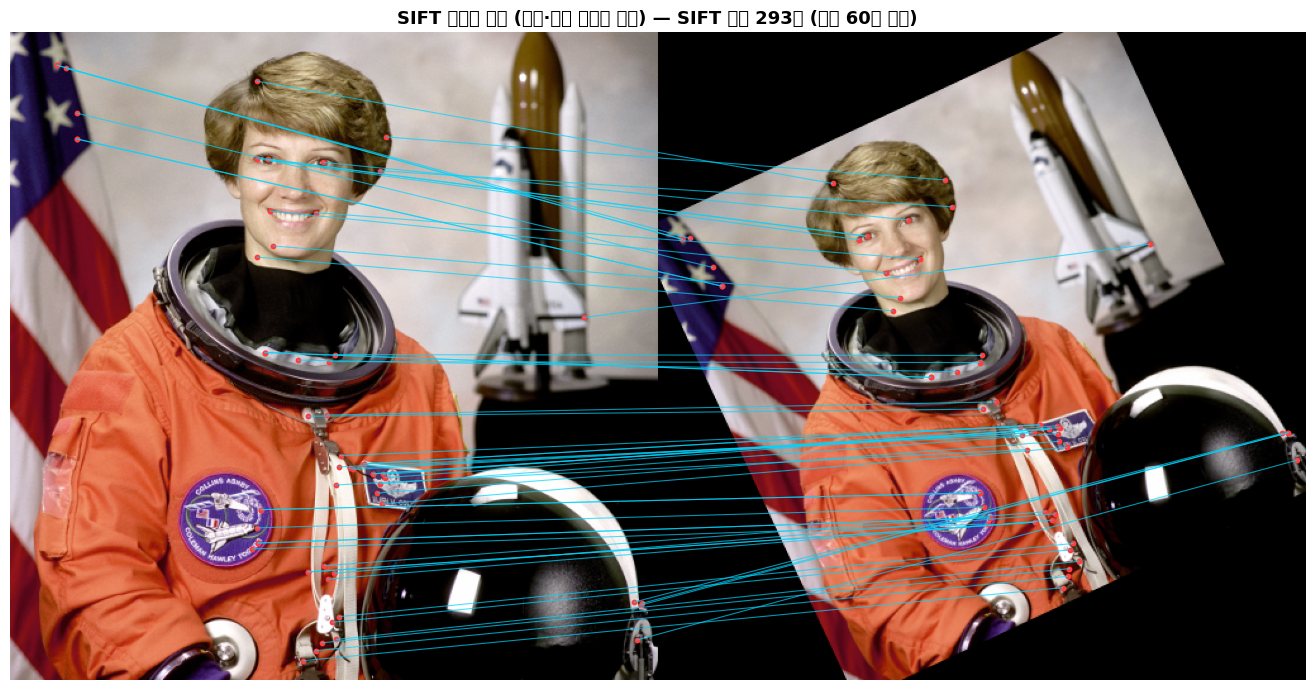

저장 완료: sift_matching_result.png / SIFT 매칭 수: 293


In [7]:
sift_result = sift_use_case.run(gray_a, base_rgb, gray_b, transformed_rgb)
SIFT_visualizer = FeatureMatchVisualizer(title="SIFT 특징점 매칭 (회전·크기 변화에 강인)")
SIFT_visualizer.save_result(sift_result, "sift_matching_result.png")

## 셀 5: ORB 구성 — 같은 유스케이스 코드, 어댑터만 교체(OCP/LSP 확인용)

In [8]:
# NORM_HAMMING을 쓰는 것 외에는 FeatureMatchingUseCase를 한 줄도 바꾸지 않는다.
orb_extractor: FeatureExtractor = ORBFeatureExtractor(n_features=500)
orb_matcher: FeatureMatcher = RatioTestBFMatcher(norm_type=cv2.NORM_HAMMING, ratio_threshold=0.75)
orb_use_case = FeatureMatchingUseCase(extractor=orb_extractor, matcher=orb_matcher)

## 셀 6: ORB 실행 및 결과 저장

/tmp/ipykernel_5835/2088220499.py:185: UserWarning: Glyph 53945 (\N{HANGUL SYLLABLE TEUG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_5835/2088220499.py:185: UserWarning: Glyph 51669 (\N{HANGUL SYLLABLE JING}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_5835/2088220499.py:185: UserWarning: Glyph 51216 (\N{HANGUL SYLLABLE JEOM}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_5835/2088220499.py:185: UserWarning: Glyph 47588 (\N{HANGUL SYLLABLE MAE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_5835/2088220499.py:185: UserWarning: Glyph 52845 (\N{HANGUL SYLLABLE CING}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_5835/2088220499.py:185: UserWarning: Glyph 44032 (\N{HANGUL SYLLABLE GA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_5835/2088220499.py:185: UserWarning: Glyph 48333 (\N{HANGUL SYLLABLE BYEOB}) missing from font(s) DejaVu Sans.
 

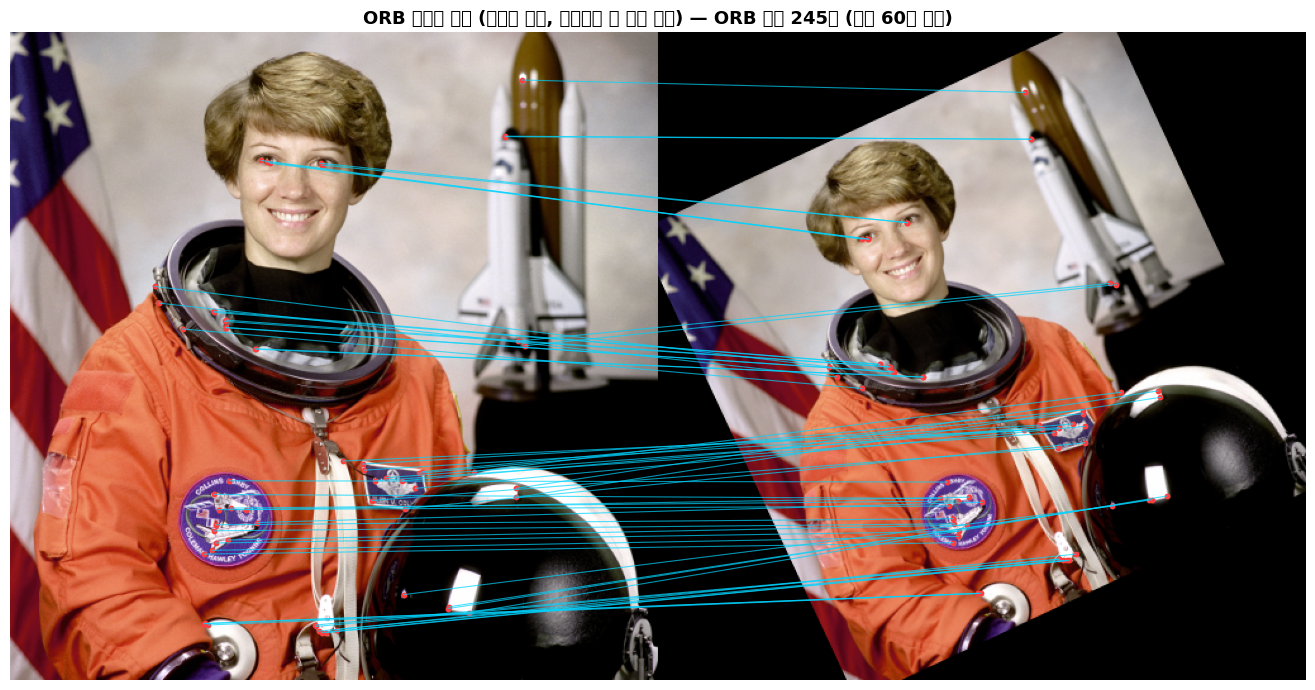

저장 완료: orb_matching_result.png / ORB 매칭 수: 245


In [9]:
orb_result = orb_use_case.run(gray_a, base_rgb, gray_b, transformed_rgb)
orb_visualizer = FeatureMatchVisualizer(title="ORB 특징점 매칭 (가볍고 무료, 실무에서 더 많이 사용)")
orb_visualizer.save_result(orb_result, "orb_matching_result.png")

## 셀 7: 두 알고리즘 비교 요약

In [10]:
print("\n=== SIFT vs ORB 비교 ===")
print(f"SIFT: 특징점 A={len(sift_result.features_a.keypoint_coords)}개, "
      f"B={len(sift_result.features_b.keypoint_coords)}개, 매칭={sift_result.match_count}쌍")
print(f"ORB : 특징점 A={len(orb_result.features_a.keypoint_coords)}개, "
      f"B={len(orb_result.features_b.keypoint_coords)}개, 매칭={orb_result.match_count}쌍")


=== SIFT vs ORB 비교 ===
SIFT: 특징점 A=500개, B=500개, 매칭=293쌍
ORB : 특징점 A=500개, B=500개, 매칭=245쌍
